In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from src.analysis_utils import (
    drop_missing,
    subset_variables,
    recode_vaccination_variables,
    chi2_cramers_v_weighted,
    normalized_crosstab,
    screen_categorical_associations,
    fit_weighted_logit,
    fit_weighted_ordinal_logit,
    extract_odds_ratios,
    plot_heatmap,
    plot_odds_ratios,
    plot_weighted_coverage_bar,
    plot_stacked_vaccination
)

In [2]:
# Path relative to script.py
csv_path = "../data/cleaned_data.csv"

# Read CSV
df = pd.read_csv(csv_path)

# Display first 5 rows
df.head()

,Mothers_id,Birth_Order,Cluster_id,Household_id,Respondents_line_number,v005,Childs_Age,Received_Hep_B_at_birth,Hep_B_1,Hep_B_2,...,hhid,Number_of_household_members,Number_of_children_under_5,Result_of_household_interview,Region,Type_of_place_of_residence,Translator_used,Vaccination_at_Birth,Vaccination_Flag,wt
0,205 12 2,2,205,12,2,552441,14,Vaccination date on card,No,No,...,205 12,4,2,Completed,Kampot,Urban,No,True,None Post Birth,0.552441
1,512 26 7,1,512,26,7,297079,8,Vaccination date on card,No,No,...,512 26,14,3,Completed,Preah Sihanouk,Rural,No,True,None Post Birth,0.297079
2,512 29 5,1,512,29,5,297079,4,No,No,No,...,512 29,6,1,Completed,Preah Sihanouk,Rural,No,False,None Post Birth,0.297079
3,641 16 1,2,641,16,1,64896,21,Vaccination date on card,No,No,...,641 16,3,2,Completed,Kep,Urban,No,True,None Post Birth,0.064896
4,513 6 1,4,513,6,1,287780,32,No,No,No,...,513 6,6,1,Completed,Preah Sihanouk,Rural,No,False,None Post Birth,0.287780


In [3]:
df["Vaccination_at_Birth"] = df["Vaccination_at_Birth"].astype(int)

In [4]:
df["Birth_Order"].value_counts().sort_index()

Birth_Order
1     1613
2     1715
3      942
4      316
5      137
6       51
7       23
8        5
9        7
10       4
13       1
Name: count, dtype: int64

In [5]:
bord_test_df = df[df['Birth_Order'] <= 6].copy()
bord_test_df = drop_missing(bord_test_df, ["Birth_Order", "Vaccination_at_Birth", "wt"])
bord_test_df = recode_vaccination_variables(bord_test_df)

   Birth_Order  Coverage
0            1  0.925558
1            2  0.946954
2            3  0.944062
3            4  0.896086
4            5  0.906217
5            6  0.810749


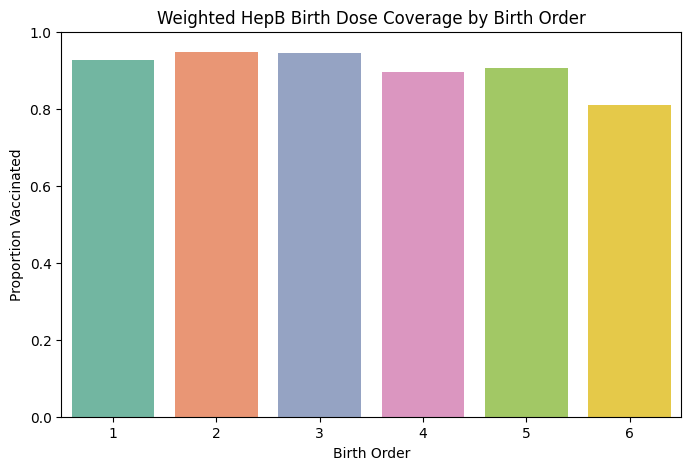

In [6]:
# ---------------------------------------------------
# Proportion of Birth Dose Coverage by Birth Order
# ---------------------------------------------------

coverage_birth = (
    bord_test_df.groupby("Birth_Order").apply(
        lambda x: pd.Series({
            "Coverage": (x["Vaccination_at_Birth"] * x["wt"]).sum() / x["wt"].sum()
        }),
        include_groups=False
    ).reset_index()
)
print(coverage_birth)


plt.figure(figsize=(8,5))
sns.barplot(data=coverage_birth, x="Birth_Order", y="Coverage", hue="Birth_Order", palette="Set2", legend=False)
plt.title("Weighted HepB Birth Dose Coverage by Birth Order")
plt.ylabel("Proportion Vaccinated")
plt.xlabel("Birth Order")
plt.ylim(0,1)
plt.savefig("../output/Birth_order_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# ---------------------------------------------------
# Binary Logistic Rregression: Birth Order
# ---------------------------------------------------
df_binary_bo, fit_stats_binary_bo = fit_weighted_logit(
    df=bord_test_df,
    formula="Vaccination_at_Birth_bin ~ Birth_Order",
    weight_col="wt")

print("=== Binary Logit: Odds Ratios ===")
print(df_binary_bo)

print("\n=== Binary Logit: Model Fit ===")
for k, v in fit_stats_binary_bo.items():
    print(f"  {k}: {v}")

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
C:\Users\oscar\anaconda3\envs\Vaccination_Cambodia\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "Respondent_country_of_birth". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


=== Binary Logit: Odds Ratios ===
                    OR   CI_lower   CI_upper    t_value       p_value
(Intercept)  17.144698  12.139045  24.214481  16.131845  4.803054e-57
Birth_Order   0.911605   0.793796   1.046897  -1.310856  1.899695e-01

=== Binary Logit: Model Fit ===
  n: 4774
  log_likelihood: -1164.5311634964016
  null_log_likelihood: -1166.1296446130996
  mcfadden_r2: 0.001370757637525144
  aic: 2332.898011971607
  bic: 2346.0042066066007


In [8]:
# ---------------------------------------------------
# Ordinal Logistic Rregression: Birth Order
# ---------------------------------------------------
df_ordinal_bo, fit_stats_ordinal_bo = fit_weighted_ordinal_logit(
    df=bord_test_df,
    outcome="Vaccination_Flag_ord",
    predictors=["Birth_Order"],
    weight_col="wt"
)

print("=== Ordinal Logit: Odds Ratios ===")
print(df_ordinal_bo)

print("\n=== Ordinal Logit: Model Fit ===")
for k, v in fit_stats_ordinal_bo.items():
    print(f"  {k}: {v}")

C:\Users\oscar\anaconda3\envs\Vaccination_Cambodia\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "Respondent_country_of_birth". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


=== Ordinal Logit: Odds Ratios ===
                   OR  CI_lower  CI_upper    t_value   p_value
Birth_Order  0.891570  0.812367  0.978494  -2.418028  0.015605
0|1          0.058062  0.046049  0.073208 -24.067242  0.000000
1|2          0.093768  0.074105  0.118649 -19.712241  0.000000
2|3          0.140311  0.111048  0.177285 -16.456826  0.000000

=== Ordinal Logit: Model Fit ===
  n: 4774
  log_likelihood: -2802.6090274321496
  null_log_likelihood: -2807.682401201366
  mcfadden_r2: 0.0018069614166635883
  aic: 5613.218054864299
  bic: 5639.101814091894


<Axes: xlabel='Birth Order', ylabel='Proportion'>

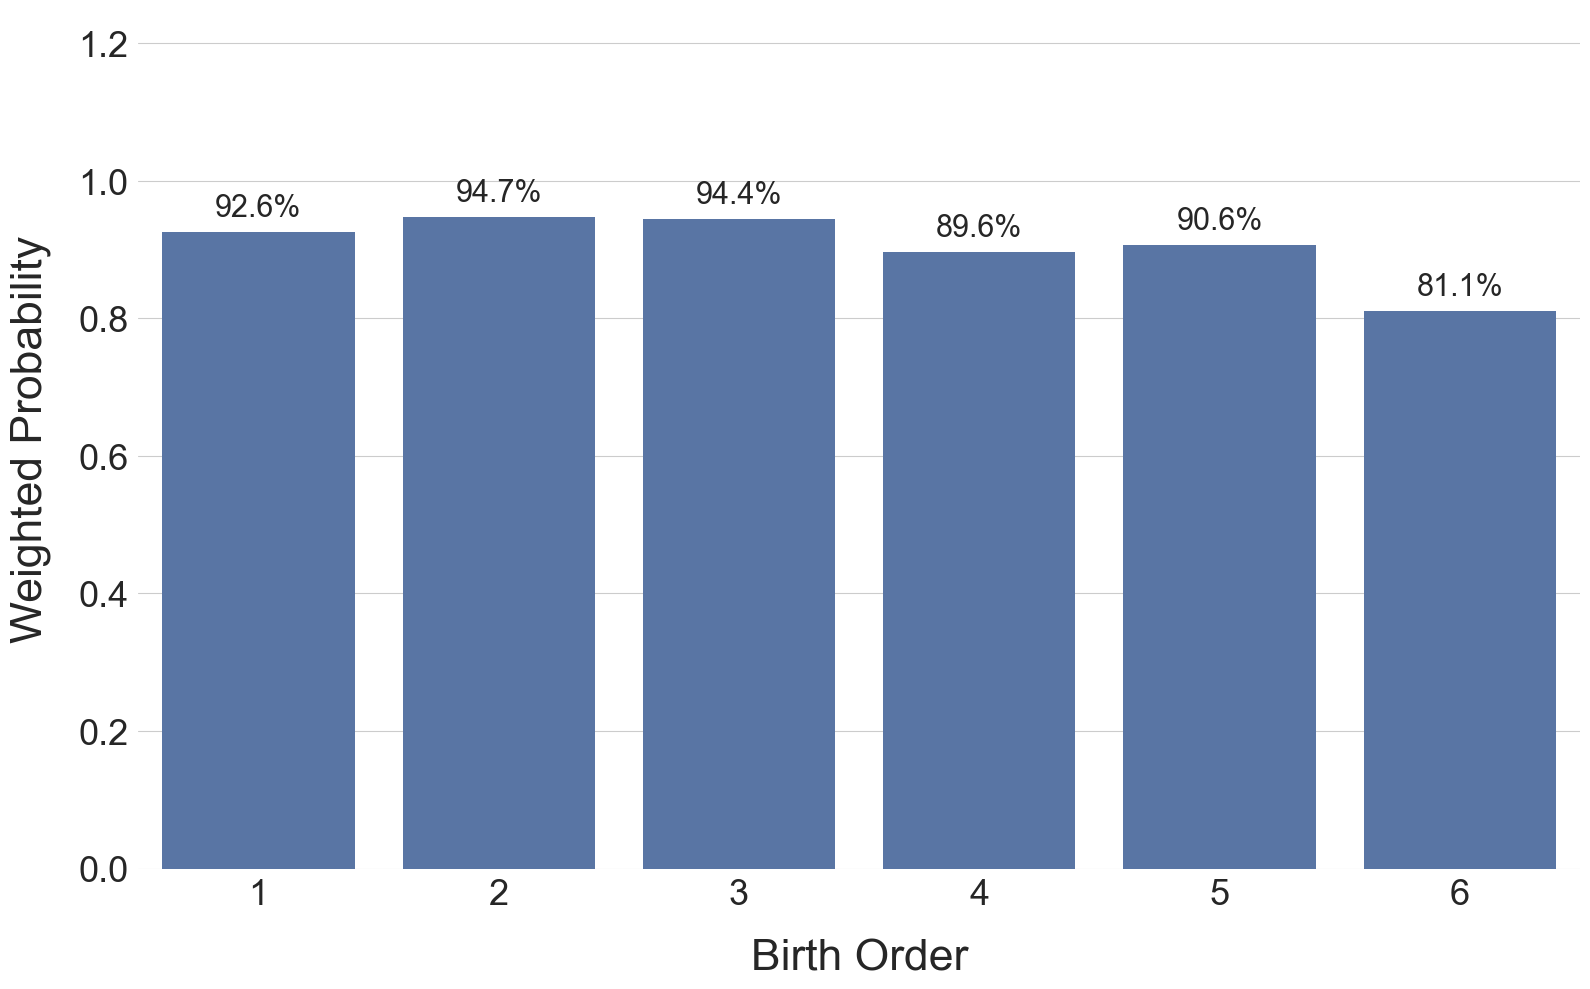

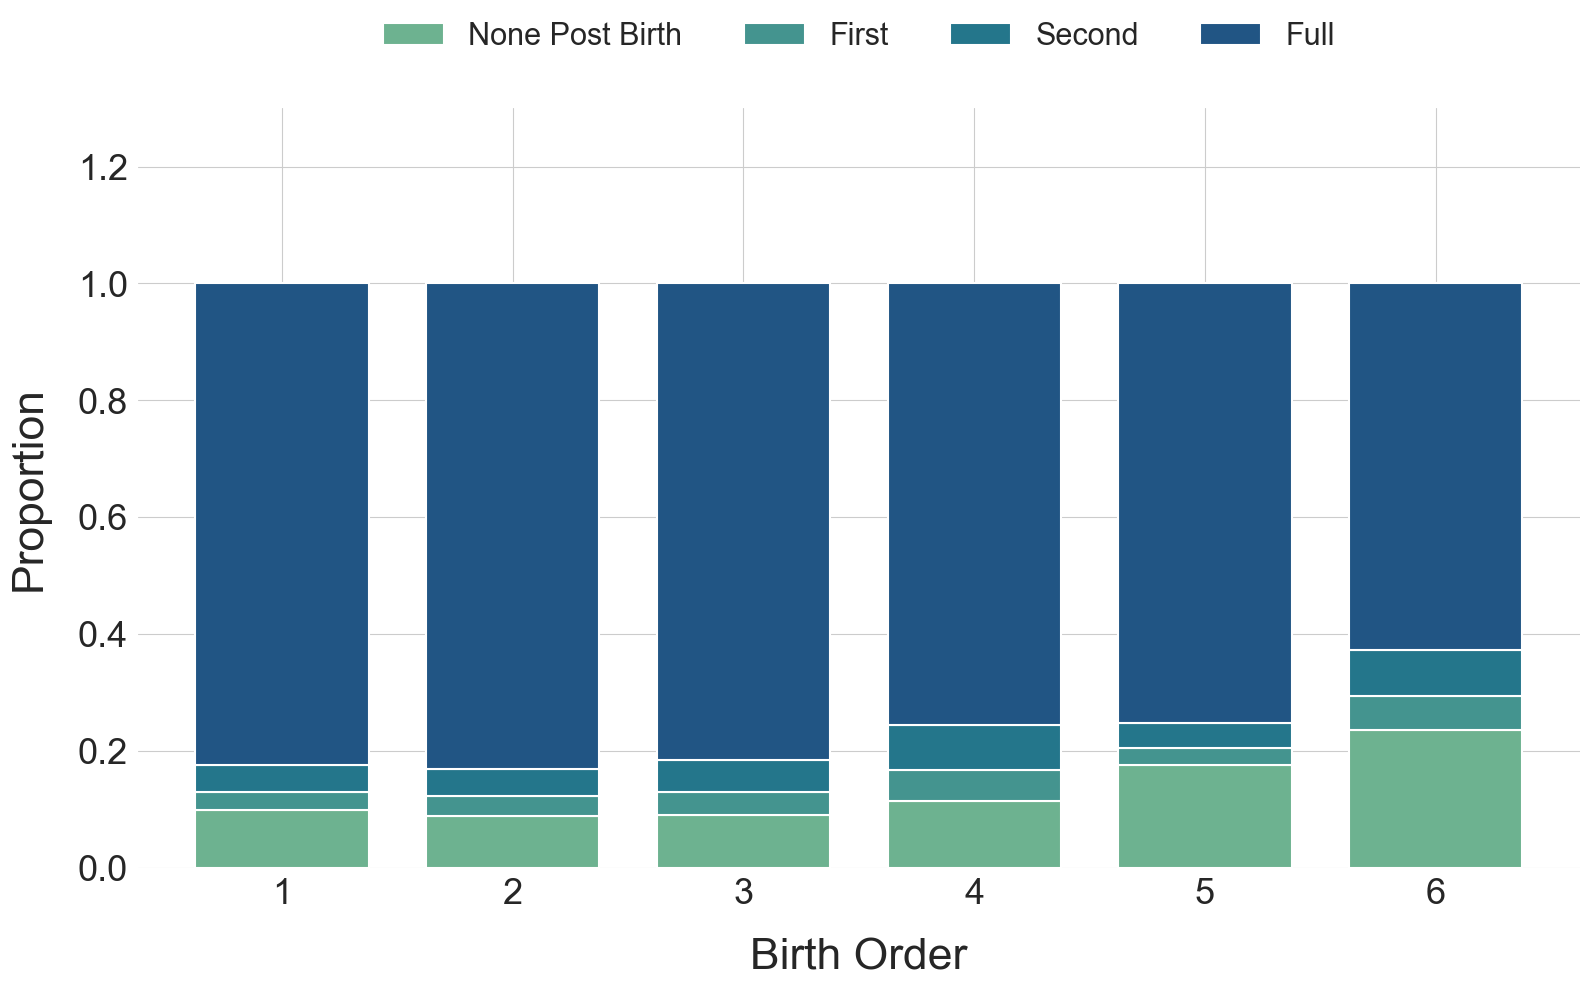

In [9]:
# ---------------------------------------------------
# 1. Encoding & Data Prep
# ---------------------------------------------------
bord_test_df = recode_vaccination_variables(bord_test_df)
viz_df = drop_missing(
    bord_test_df[bord_test_df['Birth_Order'] <= 6].copy(),
    ['Vaccination_at_Birth', 'Vaccination_Flag', 'wt']
)

# ---------------------------------------------------
# 2. Weighted Stats
# ---------------------------------------------------
coverage_birth = viz_df.groupby("Birth_Order").apply(
    lambda x: np.average(x["Vaccination_at_Birth_bin"], weights=x["wt"]),
    include_groups=False
).reset_index(name="Coverage")

vax_comp = normalized_crosstab(viz_df, 'Birth_Order', 'Vaccination_Flag')[
    ['None Post Birth', 'First', 'Second', 'Full']
]
# ---------------------------------------------------
# 3. Plotting
# ---------------------------------------------------
plot_weighted_coverage_bar(
    coverage_birth,
    x="Birth_Order",
    y="Coverage",
    xlabel="Birth Order",
    save_path="../output/Birth_coverage_by_birth_order.png"
)

plot_stacked_vaccination(
    vax_comp,
    xlabel="Birth Order",
    save_path="../output/Post_birth_coverage_by_birth_order.png"
)

In [10]:
# ---------------------------------------------------
# Creating DataFrame for Sibling History
# ---------------------------------------------------

sib_df = drop_missing(
    df[["Mothers_id", "Birth_Order", "Vaccination_Flag", "Vaccination_at_Birth", "wt"]].copy(),
    ["Mothers_id", "Birth_Order", "Vaccination_Flag", "Vaccination_at_Birth", "wt"]
)
sib_df = recode_vaccination_variables(sib_df)
sib_df["Birth_Order"] = sib_df["Birth_Order"].astype(int)
sib_df = sib_df.sort_values(["Mothers_id", "Birth_Order"])

sib_df["Prev_Vax_at_Birth"] = sib_df.groupby("Mothers_id")["Vaccination_at_Birth"].shift(1)

sib_df["History_Cat"] = pd.Categorical(
    sib_df["Prev_Vax_at_Birth"].map(
        lambda x: "0_No_Prev_Data" if pd.isnull(x)
        else ("2_Prev_Child_Yes" if x == 1 else "1_Prev_Child_No")
    ),
    categories=["0_No_Prev_Data", "1_Prev_Child_No", "2_Prev_Child_Yes"]
)

In [11]:
# ---------------------------------------------------
# Binary Logistic Rregression: Sibling History
# ---------------------------------------------------
df_binary_sh, fit_stats_binary_sh = fit_weighted_logit(
    df=sib_df,
    formula="Vaccination_at_Birth ~ History_Cat",
    weight_col="wt")

print("=== Binary Logit: Odds Ratios ===")
print(df_binary_sh)

print("\n=== Binary Logit: Model Fit ===")
for k, v in fit_stats_binary_sh.items():
    print(f"  {k}: {v}")

=== Binary Logit: Odds Ratios ===
                                    OR   CI_lower   CI_upper    t_value  \
(Intercept)                  13.986231  12.091853  16.177393  35.526819   
History_Cat1_Prev_Child_No    0.118252   0.039066   0.357947  -3.778081   
History_Cat2_Prev_Child_Yes   1.462481   0.638485   3.349886   0.898975   

                                   p_value  
(Intercept)                  1.036393e-245  
History_Cat1_Prev_Child_No    1.599520e-04  
History_Cat2_Prev_Child_Yes   3.687110e-01  

=== Binary Logit: Model Fit ===
  n: 4814
  log_likelihood: -1176.222577381247
  null_log_likelihood: -1185.7276970526439
  mcfadden_r2: 0.008016275317700439
  aic: 2359.0908186950514
  bic: 2377.883005617523


In [13]:
# ---------------------------------------------------
# Ordinal Logistic Rregression: Sibling History
# ---------------------------------------------------
df_ordinal_sh, fit_stats_ordinal_sh = fit_weighted_ordinal_logit(
    df=sib_df,
    outcome="Vaccination_Flag_ord",
    predictors=["History_Cat"],
    weight_col="wt"
)

print("=== Ordinal Logit: Odds Ratios ===")
print(df_ordinal_sh)

print("\n=== Ordinal Logit: Model Fit ===")
for k, v in fit_stats_ordinal_sh.items():
    print(f"  {k}: {v}")

=== Ordinal Logit: Odds Ratios ===
                                   OR  CI_lower  CI_upper    t_value   p_value
History_Cat1_Prev_Child_No   0.130849  0.038025  0.450263  -3.225531  0.001257
History_Cat2_Prev_Child_Yes  0.839881  0.557630  1.264998  -0.835054  0.403687
0|1                          0.073242  0.064739  0.082863 -41.513690  0.000000
1|2                          0.119451  0.106266  0.134271 -35.609092  0.000000
2|3                          0.178594  0.161104  0.197982 -32.760439  0.000000

=== Ordinal Logit: Model Fit ===
  n: 4814
  log_likelihood: -2854.0191926549346
  null_log_likelihood: -2864.864173563479
  mcfadden_r2: 0.003785513117382844
  aic: 5718.038385309869
  bic: 5750.434803401585


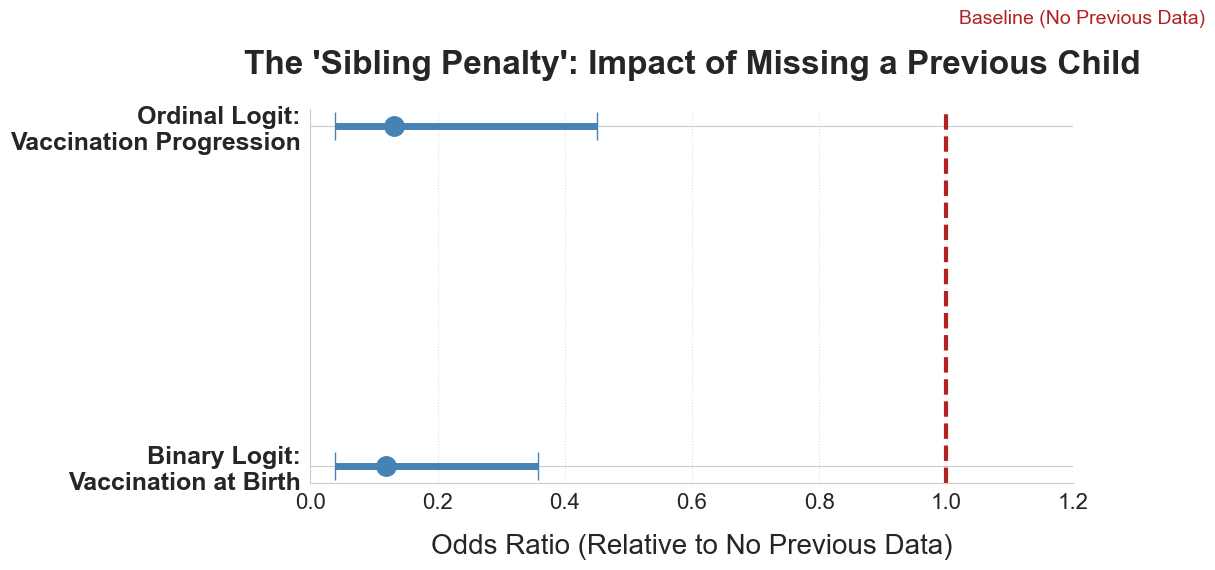

In [15]:
# ---------------------------------------------------
# Forest Plot: Negative SIbling History
# ---------------------------------------------------
bin_row = "History_Cat1_Prev_Child_No"
ord_row = "History_Cat1_Prev_Child_No"

plot_df = pd.DataFrame({
    "Model": [
        "Binary Logit:\nVaccination at Birth",
        "Ordinal Logit:\nVaccination Progression"
    ],
    "OR":     [df_binary_sh.loc[bin_row, "OR"],       df_ordinal_sh.loc[ord_row, "OR"]],
    "CI_low": [df_binary_sh.loc[bin_row, "CI_lower"],  df_ordinal_sh.loc[ord_row, "CI_lower"]],
    "CI_high":[df_binary_sh.loc[bin_row, "CI_upper"],  df_ordinal_sh.loc[ord_row, "CI_upper"]]
})

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(plot_df))
ax.errorbar(
    plot_df["OR"], y_pos,
    xerr=[plot_df["OR"] - plot_df["CI_low"], plot_df["CI_high"] - plot_df["OR"]],
    fmt='o', capsize=10, ms=14, elinewidth=5, color='steelblue',
    label='Sibling Penalty (vs No Previous Data)'
)
ax.axvline(1, color='firebrick', linestyle='--', linewidth=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["Model"], fontsize=18, fontweight='bold')
ax.set_xlabel("Odds Ratio (Relative to No Previous Data)", fontsize=20, labelpad=15)
ax.set_title("The 'Sibling Penalty': Impact of Missing a Previous Child",
             fontsize=24, pad=25, fontweight='bold')
ax.set_xlim(0, max(plot_df["CI_high"].max() * 1.15, 1.2))
ax.tick_params(axis='x', labelsize=16)
ax.text(1.02, 1.3, "Baseline (No Previous Data)", color='firebrick', fontsize=14)
ax.grid(True, axis='x', linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("../output/Negative_sibling_history_forest_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
# ---------------------------------------------------
# Multivariate Model Data Preperation
# ---------------------------------------------------

model_cols = [
    "Mothers_id",
    "Birth_Order",
    "Vaccination_Flag",
    "Vaccination_at_Birth",
    "Mothers_age",
    "Wealth_index_combined",
    "Type_of_place_of_residence",
    "Number_of_antenatal_visits_during_pregnancy",
    "wt"
]

mv_ord_df = drop_missing(df[model_cols].copy(), model_cols)
mv_ord_df = recode_vaccination_variables(mv_ord_df)

# Ensure correct types
mv_ord_df["Birth_Order"] = mv_ord_df["Birth_Order"].astype(int)
mv_ord_df["Vaccination_at_Birth"] = pd.to_numeric(
    mv_ord_df["Vaccination_at_Birth"], errors="coerce"
).astype(int)

# --- History variable ---
mv_ord_df = mv_ord_df.sort_values(["Mothers_id", "Birth_Order"])
mv_ord_df["Prev_Stat"] = mv_ord_df.groupby("Mothers_id")["Vaccination_at_Birth"].shift(1)

mv_ord_df["History_Cat"] = pd.Categorical(
    mv_ord_df["Prev_Stat"].map(
        lambda x: "0_No_Prev_Data" if pd.isnull(x)
        else ("2_Prev_Child_Yes" if x == 1 else "1_Prev_Child_No")
    ),
    categories=["0_No_Prev_Data", "1_Prev_Child_No", "2_Prev_Child_Yes"]
)

# --- Age categories ---
mv_ord_df["Age_Cat"] = pd.Categorical(
    pd.cut(
        mv_ord_df["Mothers_age"],
        bins=[0, 24, 34, 50],
        labels=["15-24", "25-34", "35-49"]
    ),
    categories=["25-34", "15-24", "35-49"]
)

# --- Wealth reference ---
mv_ord_df["Wealth_Ref"] = pd.Categorical(
    mv_ord_df["Wealth_index_combined"],
    categories=["Middle", "Poorest", "Poorer", "Richer", "Richest"]
)

# --- Residence ---
mv_ord_df["Residence"] = pd.Categorical(
    mv_ord_df["Type_of_place_of_residence"],
    categories=["Urban", "Rural"]
)

In [17]:
# ---------------------------------------------------
# Binary Logistic Rregression: Multivariate Model
# ---------------------------------------------------

bin_or_df, bin_fit = fit_weighted_logit(
    df=mv_ord_df,
    formula=(
        "Vaccination_at_Birth ~ History_Cat + Birth_Order + Age_Cat"
        " + Wealth_Ref + Residence + Number_of_antenatal_visits_during_pregnancy"
    ),
    weight_col="wt"
)

# Remove intercept (not used in forest plot)
bin_or_df = bin_or_df[~bin_or_df.index.str.contains("Intercept")]

print(f"\nMULTIVARIATE LOGIT: VACCINATION AT BIRTH (N={bin_fit['n']})")
print(bin_or_df.drop(columns="t_value"))


MULTIVARIATE LOGIT: VACCINATION AT BIRTH (N=4814)
                                                   OR  CI_lower  CI_upper  \
History_Cat1_Prev_Child_No                   0.176828  0.047943  0.652191   
History_Cat2_Prev_Child_Yes                  1.739721  0.741594  4.081246   
Birth_Order                                  0.882122  0.759882  1.024027   
Age_Cat.L                                    0.848790  0.612814  1.175633   
Age_Cat.Q                                    1.519444  1.087337  2.123268   
Wealth_RefPoorest                            0.616033  0.412357  0.920309   
Wealth_RefPoorer                             1.118508  0.705495  1.773306   
Wealth_RefRicher                             1.145308  0.696521  1.883261   
Wealth_RefRichest                            0.823388  0.471242  1.438681   
ResidenceRural                               0.869770  0.615665  1.228752   
Number_of_antenatal_visits_during_pregnancy  1.120544  1.061702  1.182647   

                        

In [18]:
# ---------------------------------------------------
# Ordinal Logistic Rregression: Multivariate Model
# ---------------------------------------------------

ord_or_df, ord_fit = fit_weighted_ordinal_logit(
    df=mv_ord_df,
    outcome="Vaccination_Flag_ord",
    predictors=[
        "History_Cat",
        "Birth_Order",
        "Age_Cat",
        "Wealth_Ref",
        "Residence",
        "Number_of_antenatal_visits_during_pregnancy"
    ],
    weight_col="wt"
)

# Remove threshold cutpoints (0|1, 1|2, 2|3)
ord_or_df = ord_or_df[
    ~ord_or_df.index.str.contains(r"\|")
]

print(f"\nFINAL MULTIVARIATE ORDERED LOGIT (N={ord_fit['n']})")
print(ord_or_df.drop(columns="t_value"))


FINAL MULTIVARIATE ORDERED LOGIT (N=4814)
                                                   OR  CI_lower  CI_upper  \
History_Cat1_Prev_Child_No                   0.239439  0.079335  0.722651   
History_Cat2_Prev_Child_Yes                  1.104547  0.715479  1.705185   
Birth_Order                                  0.800833  0.725152  0.884413   
Age_Cat.L                                    1.146140  0.927152  1.416852   
Age_Cat.Q                                    1.757404  1.381522  2.235554   
Wealth_RefPoorest                            0.650460  0.494696  0.855268   
Wealth_RefPoorer                             1.069033  0.786178  1.453655   
Wealth_RefRicher                             1.152519  0.812620  1.634589   
Wealth_RefRichest                            0.906851  0.618062  1.330576   
ResidenceRural                               1.159947  0.911689  1.475805   
Number_of_antenatal_visits_during_pregnancy  1.199278  1.155454  1.244763   

                                

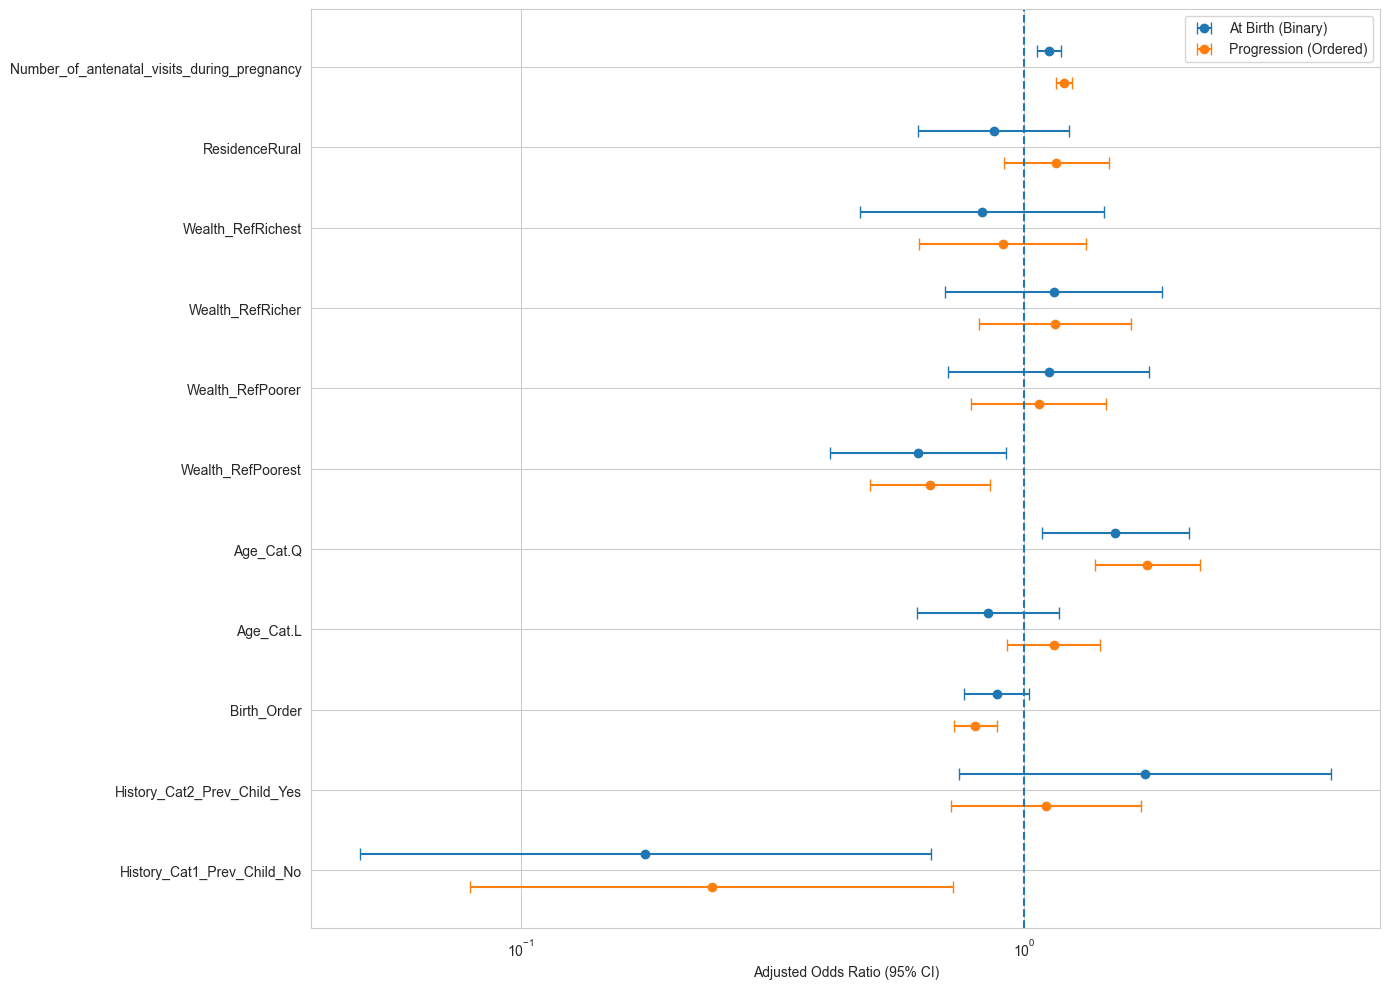

In [19]:
# ---------------------------------------------------
# Forest Plot: Multivariate Model
# ---------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# Align variables
all_vars = bin_or_df.index.union(ord_or_df.index)

combined_df = pd.DataFrame({
    "Variable": all_vars,
    "OR_Birth": bin_or_df.reindex(all_vars)["OR"],
    "LCI_Birth": bin_or_df.reindex(all_vars)["CI_lower"],
    "UCI_Birth": bin_or_df.reindex(all_vars)["CI_upper"],
    "OR_Prog": ord_or_df.reindex(all_vars)["OR"],
    "LCI_Prog": ord_or_df.reindex(all_vars)["CI_lower"],
    "UCI_Prog": ord_or_df.reindex(all_vars)["CI_upper"],
}).dropna(subset=["OR_Birth", "OR_Prog"], how="all").reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
y_pos = np.arange(len(combined_df))

# Birth model
ax.errorbar(
    combined_df["OR_Birth"],
    y_pos + 0.2,
    xerr=[
        combined_df["OR_Birth"] - combined_df["LCI_Birth"],
        combined_df["UCI_Birth"] - combined_df["OR_Birth"],
    ],
    fmt="o",
    capsize=4,
    label="At Birth (Binary)"
)

# Progression model
ax.errorbar(
    combined_df["OR_Prog"],
    y_pos - 0.2,
    xerr=[
        combined_df["OR_Prog"] - combined_df["LCI_Prog"],
        combined_df["UCI_Prog"] - combined_df["OR_Prog"],
    ],
    fmt="o",
    capsize=4,
    label="Progression (Ordered)"
)

ax.axvline(1, linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(combined_df["Variable"])
ax.set_xscale("log")
ax.set_xlabel("Adjusted Odds Ratio (95% CI)")
ax.legend()

plt.tight_layout()
plt.savefig("../output/Full_multivariate_forest_plot.png", dpi=300, bbox_inches="tight")
plt.show()